In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')

mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")

In [8]:
def _calculate_md(pos):
    num_steps = len(pos)
    md = []
    std = []
    for tau in range(1, num_steps):
        displacements = pos[tau:] - pos[:-tau]
        #print(displacements.shape)
        md_tau = np.mean(displacements, axis = 0)
        std_tau = np.std(displacements, axis = 0)
        md.append(md_tau)
        std.append(std_tau)
    
    return np.array(md), np.array(std)

def imd(df, scale = 1, time_scale = 1):
    md_df = pd.DataFrame(columns=['particle', 'lag time', 'dx', 'dy'])

    for particle_id, group in df.groupby('particle'):
        data = pd.DataFrame()
        group = group.sort_values(by='frame')  # フレーム順に並べ替え
        x = scale * group['x'].to_numpy()
        y = scale * group['y'].to_numpy()
        pos = np.array([x, y]).T
        lag_t = time_scale * np.arange(1,pos.shape[0])
        md, std =_calculate_md(pos)
        data = pd.DataFrame({'particle':particle_id, 'lag time':lag_t, 'dx':md[:,0], 'dy':md[:,1]})

        md_df=pd.concat([md_df, data])


    return md_df

def emd(imd_list):
    emd_x=imd_list.groupby('lag time').mean()['dx']
    emd_std_x = imd_list.groupby('lag time').std()['dx']
    emd_y=imd_list.groupby('lag time').mean()['dy']
    emd_std_y = imd_list.groupby('lag time').std()['dy']

    return emd_x, emd_std_x, emd_y, emd_std_y

def concatMD(path_list, interval_list, scale = 0.11):
    IMD_list = []
    for i in range(len(path_list)):
        print(path_list[i])
        df = pd.read_csv(path_list[i])
        IMD = imd(df, scale, interval_list[i])
        IMD['particle'] += 10000*i
        IMD_list.append(IMD)

    return pd.concat(IMD_list)

In [9]:
I_concat = concatMD([path0, path1, path2, path3, path4], [ 4, 4, 4, 4, 4])

/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001/beads_tracks.csv
/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/beads_tracks.csv


In [10]:
Mdp = I_concat.groupby('lag time').mean()
Std = I_concat.groupby('lag time').std()

[(0.0, 150.0),
 (-4.0, 4.0),
 Text(0.5, 0, 'lag time $\\Delta$ t [s]'),
 Text(0, 0.5, 'mean displacement [μm]')]

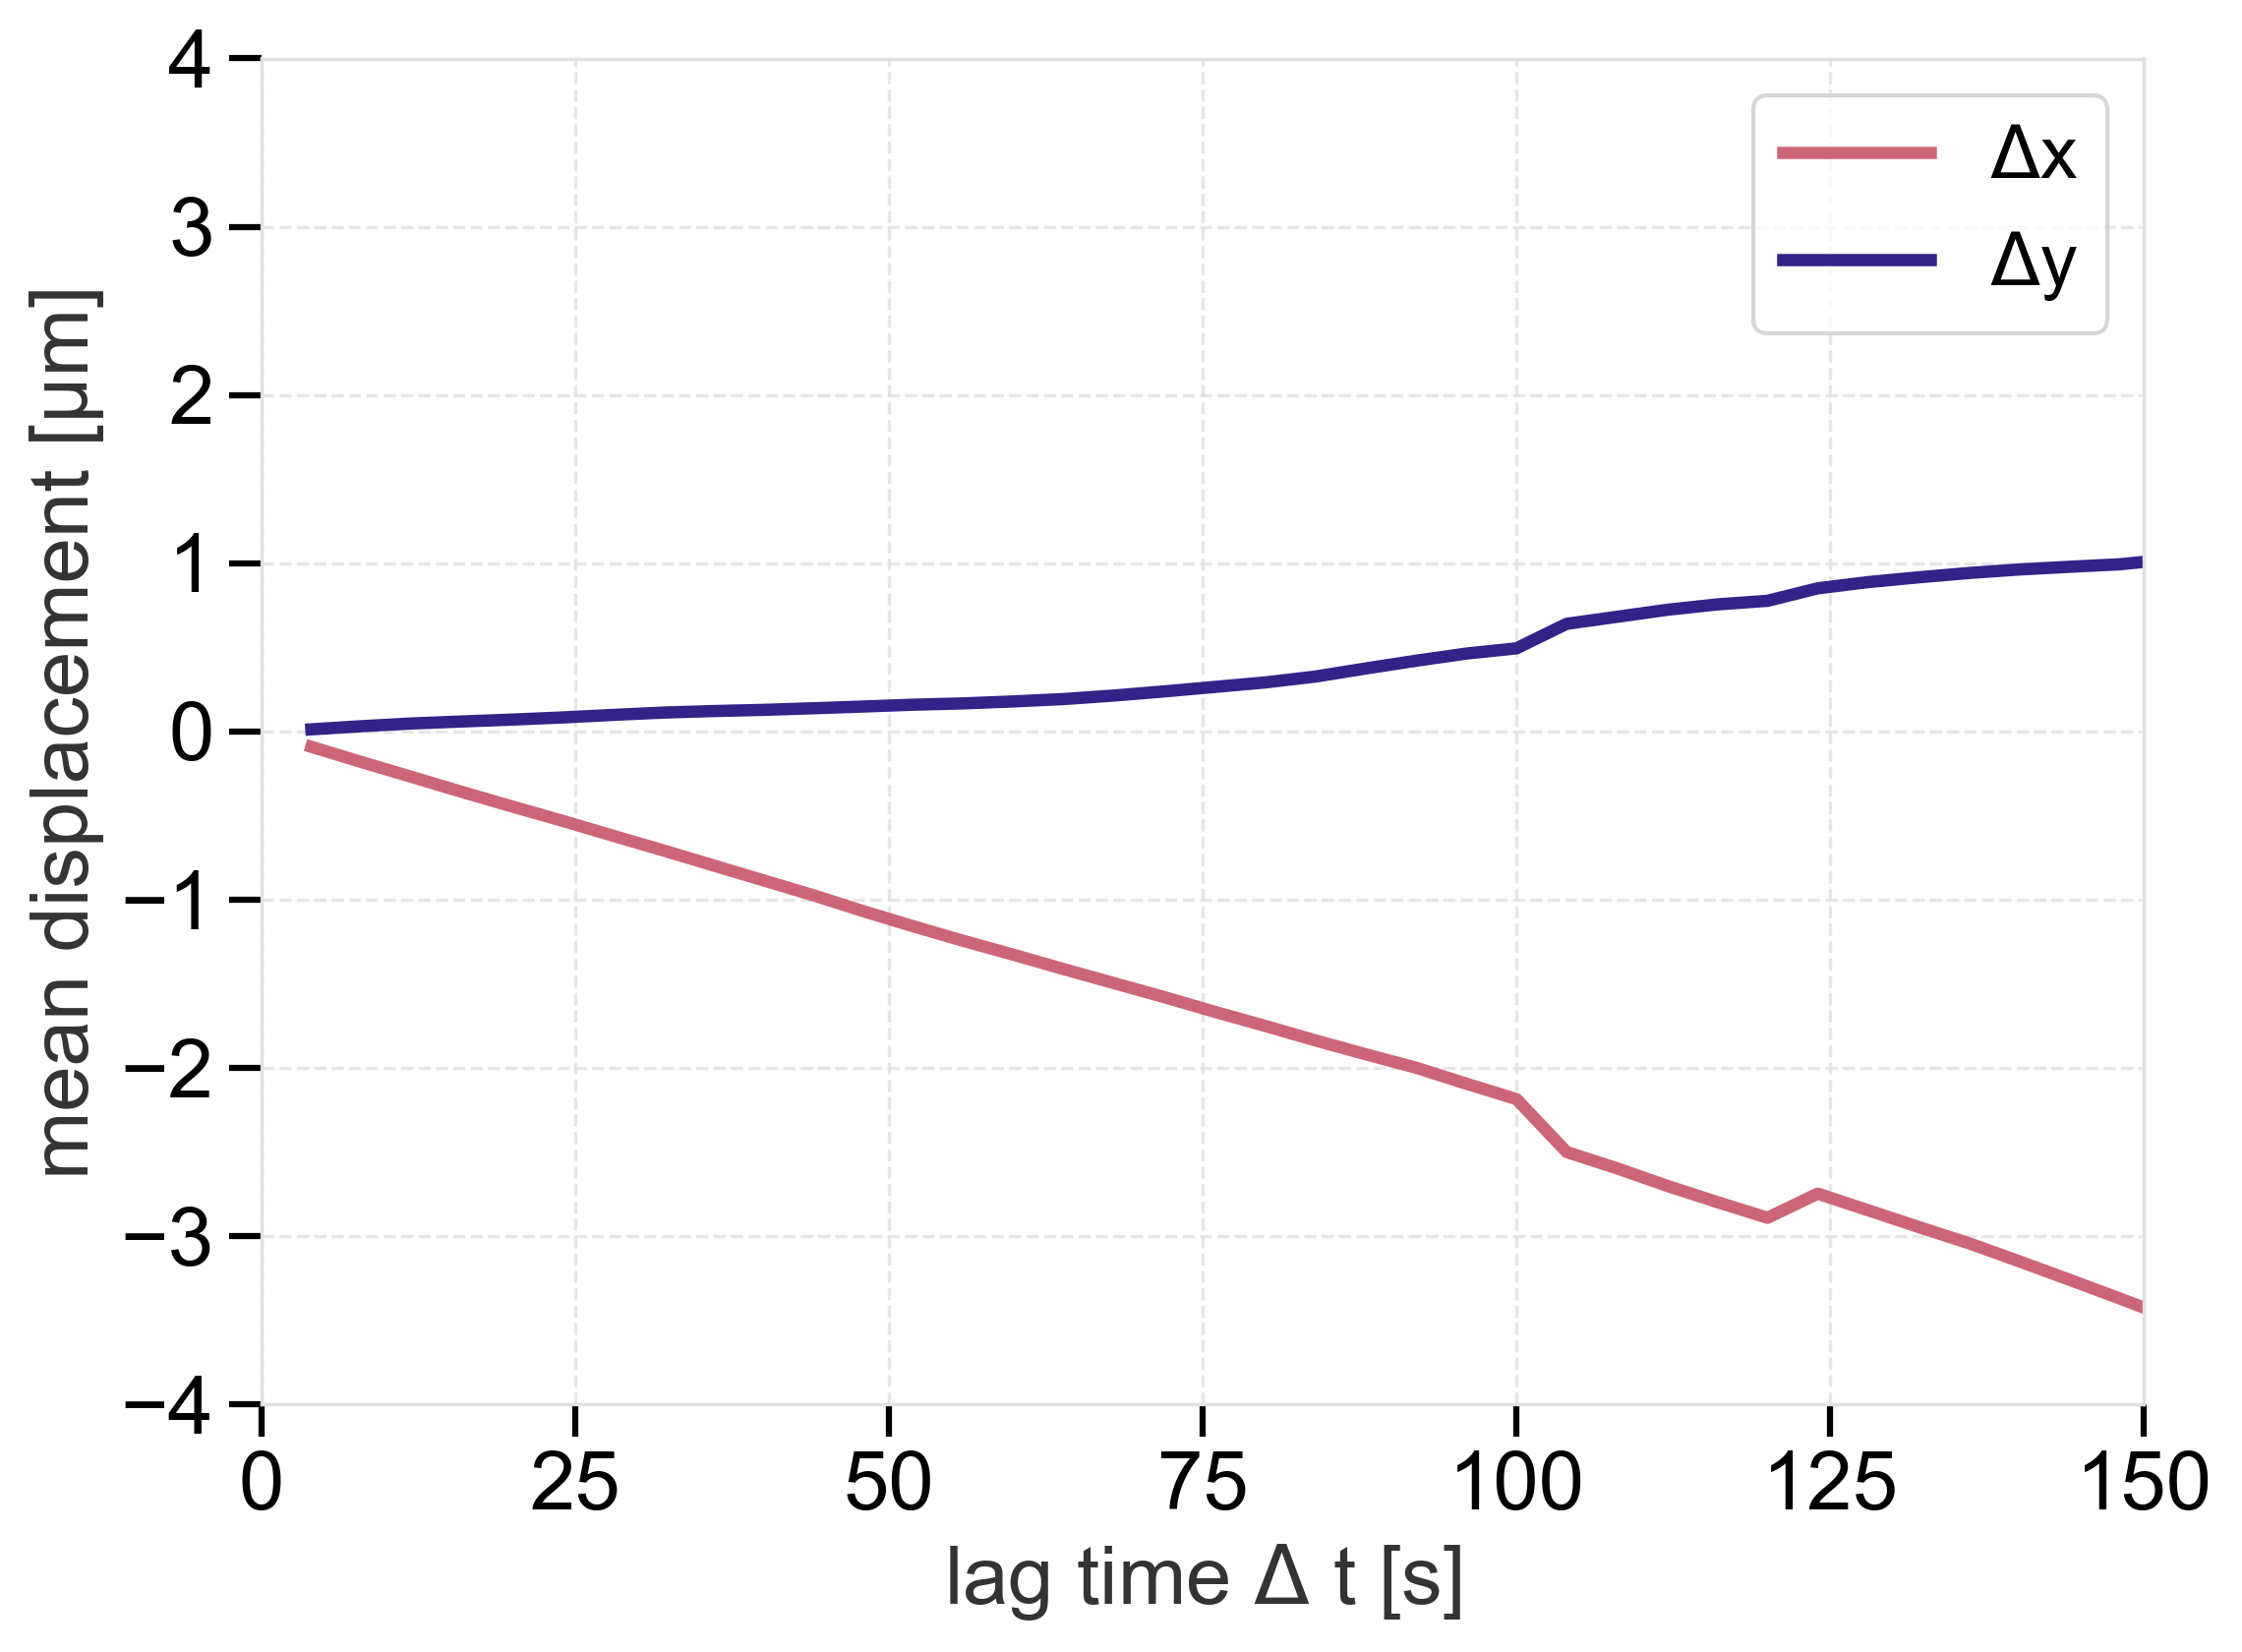

In [20]:
fig, ax = plt.subplots()

ax.plot(Mdp.index, Mdp['dx'], label = '$\\Delta$x')
#ax.fill_between(Mdp.index, Mdp['dx'] + Std['dx'], Mdp['dx'] - Std['dx'], alpha = 0.5)

ax.plot(Mdp.index, Mdp['dy'], label = '$\\Delta$y')
#ax.fill_between(Mdp.index, Mdp['Mdy']+Mdp['std_dy'], Mdp['Mdy']-Mdp['std_dy'], alpha = 0.5)

ax.legend()

ax.set(
    xlim=(0, 150),
    ylim=(-4,4),
    xlabel='lag time $\Delta$ t [s]',
    ylabel='mean displacement [\u03bcm]'
    )

In [13]:
Std

,particle,dx,dy
lag time,,,
4,13859.497787,0.267528,0.106780
8,13859.497787,0.543034,0.221403
12,13859.497787,0.816514,0.343074
16,13859.497787,1.085517,0.460519
20,13859.497787,1.352801,0.577483
...,...,...,...
3988,1.825742,24.560891,7.862586
3992,1.825742,24.514914,7.745382
3996,1.825742,24.540049,7.716975
